In [1]:
# tf dataset의 cat/dog 이미지 분류 + 전이학습 + 미세조정  : 결과보다는 과정을 이해
# 백본 : MobileNetV2
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

# tfds.disable_progress_bar()  # 진행률 표시바 비활성화
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True, # dict type으로 반환
)
print(raw_train)
print(raw_validation)
print(raw_test)
print(metadata)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.5ZPO4F_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    f

In [2]:
total = metadata.splits['train'].num_examples
print('train 전체 수 :', total)
print('raw_train 수 : ', int(total * 0.8))
print('raw_vali 수 : ', int(total * 0.1))
print('raw_test 수 : ', int(total * 0.1))
# image(원본) :  (262, 350, 3)
# label :  1

# label명 얻기
get_label_name = metadata.features['label'].int2str
print(get_label_name(0))
print(get_label_name(1))

train 전체 수 : 23262
raw_train 수 :  18609
raw_vali 수 :  2326
raw_test 수 :  2326
cat
dog


image(원본) :  (262, 350, 3)
label :  1


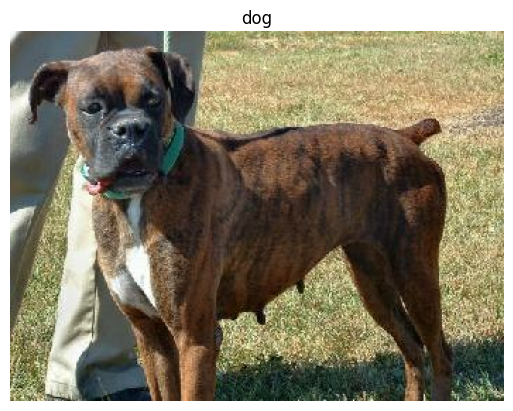

In [3]:
# 샘플 자료 보기
for image, label in raw_train.take(1):
    print('image(원본) : ', image.shape)
    print('label : ', label.numpy())
    plt.figure()
    plt.imshow(image)
    plt.title(get_label_name(label))
    plt.axis('off')
    plt.show()

In [4]:
# 전처리 함수 - cat / dog 크기가 다양함. 크기 고정. 정규화
IMG_SIZE = 160

def format_exampleFunc(image, label):
  image = tf.cast(image, tf.float32)   # uint -> float32
  image = (image/127.5) - 1             # [0, 255] -> [-1, 1]
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  return image, label

# 원본 dataset을 전처리된 dataset으로 변경
# tf.data.AUTOTUNE : 여러 개의 샘플을 병렬로 자동처리
train = raw_train.map(format_exampleFunc, tf.data.AUTOTUNE)
validation = raw_validation.map(format_exampleFunc, tf.data.AUTOTUNE)
test = raw_test.map(format_exampleFunc, tf.data.AUTOTUNE)

# 전처리 검증
for img, label in train.take(1):
  print('전처리 샘플 dtype : ', img.dtype)
  print('전처리 샘플 shape : ', img.shape)
  print('min/max :',float( tf.reduce_min(img)), '/',float( tf.reduce_max(img)))

# batch pipeline 운영
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

# train만 shuffle함 . 나머지 둘은 고정. 1000개의 샘플을 메모리에 로딩해서 섞음
# prefetch : 모델이 학습하는 동안 다음 학습에 필요한 데이터를 미리 가져와 전처리 해둠
train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_batches = validation.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_batches = test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for image_single, label_single in train_batches.take(2):
  print('원본 단일 이미지 : ', image_single.numpy().shape)
  print('라벨 : ', label_single.numpy())


전처리 샘플 dtype :  <dtype: 'float32'>
전처리 샘플 shape :  (160, 160, 3)
min/max : -1.0 / 1.0
원본 단일 이미지 :  (32, 160, 160, 3)
라벨 :  [1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 1 0]
원본 단일 이미지 :  (32, 160, 160, 3)
라벨 :  [0 0 1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 0 1 1 1 0 0 1 0]


In [5]:
# base_model
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
# print(base_model.summary())

# 전처리 / 배치가 된 텐서를 통과시켜 특징 맵 얻기
images_batch, labels_batch = next(iter(train_batches))
feature_batch = base_model(images_batch)
print(images_batch.shape)   # (32, 160, 160, 3)
print(feature_batch.shape)  # (32, 5, 5, 1280)  하나의 이미지는 (5, 5, 1280)

global_avg = tf.keras.layers.GlobalAveragePooling2D()(feature_batch)
print(global_avg.shape)  # (32, 1280) : 5 * 5 를 평균내고 채널 축만 남김(1280차 벡터 하나로 요약)
# 배치 크기는 유지하면서 최종 shape : (32, 1280)을 축만 남기면 이미지 당 한개의 고정길이 벡터를 얻어, Dens(분류기)에 넣기 쉬워진다. (GAP의 역할)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(32, 160, 160, 3)
(32, 5, 5, 1280)
(32, 1280)


In [6]:
# 모델 정의
# Seqential로 정의
# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=IMG_SHAPE),
#     base_model,
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(1, activation='sigmoid')  # base model + 이진 분류기
# ])

# Functional로 정의
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# print(model.summary())

base_model.trainable = False    # 특징 추출기(Conv + Pooling)  동결

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=10,
)

loss, acc = model.evaluate(test_batches)
print(f"loss : {loss:.4f}, acc : {acc:.4f}")

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 100ms/step - accuracy: 0.9678 - loss: 0.0865 - val_accuracy: 0.9832 - val_loss: 0.0513
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.9843 - loss: 0.0449 - val_accuracy: 0.9815 - val_loss: 0.0473
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9861 - loss: 0.0398 - val_accuracy: 0.9828 - val_loss: 0.0448
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9869 - loss: 0.0369 - val_accuracy: 0.9837 - val_loss: 0.0445
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.9893 - loss: 0.0334 - val_accuracy: 0.9854 - val_loss: 0.0435
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9889 - loss: 0.0310 - val_accuracy: 0.9854 - val_loss: 0.0456
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9900 - loss: 0.0289 - val_accuracy: 0.9854 - val_loss: 0.0456
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9909 - loss: 0.0271 -

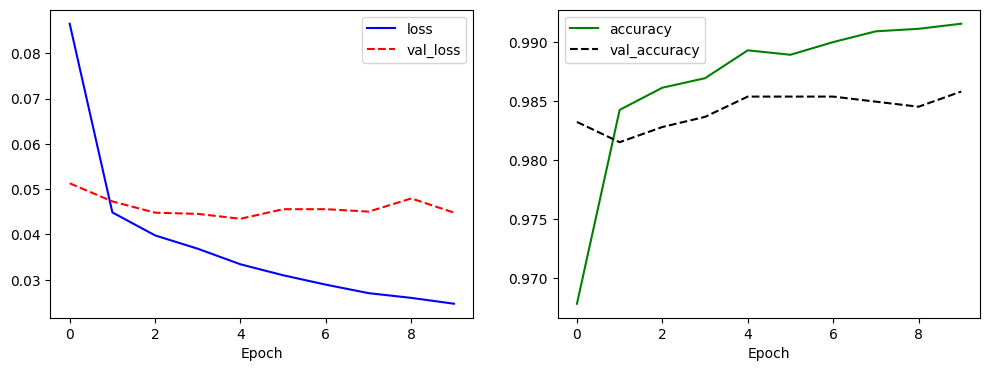

In [7]:
# 시각화
import matplotlib.pyplot as plt

# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [12]:
# 미세조정(Fine Tunning) 적용하기
# 1. 베이스 모델 동결 해제
base_model.trainable = True

# 2. 하위 층은 그대로 두고 상위 일부 층만 학습 가능하게 설정
print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. 모델 재컴파일
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Checkpoint, Earlystopping
os.makedirs('checkpoints', exist_ok=True)
ckpt_path_ft = 'checkpoints/finetune_best.keras' # .keras 확장자 추가

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path_ft,
        monitor='val_accuracy', # val_acc -> val_accuracy 로 수정
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=5,
        factor=0.5,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', # val_acc -> val_accuracy 로 수정
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

Number of layers in the base model:  154


In [13]:
EPOCHS_TRANSFER = 10
EPOCHS_FINETUNE = 10

# 미세 조정 학습 수행
history_ft = model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=EPOCHS_TRANSFER + EPOCHS_FINETUNE,
    initial_epoch=EPOCHS_TRANSFER,
    callbacks=callbacks_ft,
    verbose=1
)

# 최종 평가
loss, acc = model.evaluate(test_batches)
print(f"Final Test loss : {loss:.4f}, acc : {acc:.4f}")

Epoch 11/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9987 - loss: 0.0052
Epoch 11: val_accuracy improved from None to 0.98151, saving model to checkpoints/finetune_best.keras

Epoch 11: finished saving model to checkpoints/finetune_best.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 91ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9815 - val_loss: 0.0645 - learning_rate: 1.0000e-05
Epoch 12/20
580/582 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9988 - loss: 0.0051
Epoch 12: val_accuracy improved from 0.98151 to 0.98323, saving model to checkpoints/finetune_best.keras

Epoch 12: finished saving model to checkpoints/finetune_best.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9832 - val_loss: 0.0621 - learning_rate: 1.0000e-05
Epoch 13/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9992 - loss: 0.0042
Epoch 13: val_accuracy did not improve from 0.98323
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - ac

In [4]:
# 전체 학습 과정 시각화 (전이 학습 + 미세 조정)
import matplotlib.pyplot as plt

try:
    # 두 학습 단계의 기록을 합침
    acc = history.history['accuracy'] + history_ft.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
    loss = history.history['loss'] + history_ft.history['loss']
    val_loss = history.history['val_loss'] + history_ft.history['val_loss']

    plt.figure(figsize=(12, 8))

    # 정확도 그래프
    plt.subplot(2, 1, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.ylim([0.8, 1])
    plt.plot([EPOCHS_TRANSFER-1, EPOCHS_TRANSFER-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # 손실 그래프
    plt.subplot(2, 1, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.ylim([0, 0.2])
    plt.plot([EPOCHS_TRANSFER-1, EPOCHS_TRANSFER-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"오류 발생: {e}")
    print("\n[해결 방법]")
    print("1. '전이 학습' 셀(VOV02vSpSxt1)을 먼저 실행하여 'history'를 생성하세요.")
    print("2. '미세 조정' 셀(hE_xlFAKfiCk)을 실행하여 'history_ft'를 생성하세요.")
    print("3. 그 후 이 셀을 다시 실행하면 학습 곡선을 볼 수 있습니다.")

오류 발생: name 'history' is not defined

[해결 방법]
1. '전이 학습' 셀(VOV02vSpSxt1)을 먼저 실행하여 'history'를 생성하세요.
2. '미세 조정' 셀(hE_xlFAKfiCk)을 실행하여 'history_ft'를 생성하세요.
3. 그 후 이 셀을 다시 실행하면 학습 곡선을 볼 수 있습니다.
